<a href="https://colab.research.google.com/github/AlphaArcturus/SIT770-NLP-HD/blob/main/Self_Consistency_Prompt_Ensembling_for_Temporal_QA_v1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Experiment Notebook V2: Self-Consistency Prompt Ensembling for Temporal QA

In [ ]:
!pip install -q -U transformers accelerate pandas matplotlib tqdm

In [2]:
import torch
import re
import pandas as pd
import matplotlib.pyplot as plt
from tqdm import tqdm
from collections import Counter
from transformers import AutoTokenizer, AutoModelForCausalLM

## Cell 1: Load Qwen2.5-1.5B-Instruct

In [ ]:
MODEL_NAME = "Qwen/Qwen2.5-1.5B-Instruct"

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME, trust_remote_code=True)

model = AutoModelForCausalLM.from_pretrained(
    MODEL_NAME,
    torch_dtype=torch.float16 if torch.cuda.is_available() else torch.float32,
    device_map="auto",
    trust_remote_code=True
)

print("Loaded:", MODEL_NAME)

## Cell 2: Define Temporal QA Dataset

In [4]:
dataset = [
    [1, "Who was the president of the United States in 2012?", "Barack Obama"],
    [2, "Which country hosted the FIFA World Cup in 2014?", "Brazil"],
    [3, "In which year were the Beijing Summer Olympics held?", "2008"],
    [4, "Who was the CEO of Apple when the iPhone 4S was announced in 2011?", "Tim Cook"],
    [5, "Which company acquired Instagram in 2012?", "Facebook"],
    [6, "Who was the Prime Minister of the United Kingdom when the Brexit referendum was held in 2016?", "David Cameron"],
    [7, "Which country hosted the 2016 Summer Olympics?", "Brazil"],
    [8, "Who was the president of South Africa when Nelson Mandela died in 2013?", "Jacob Zuma"],
    [9, "In which year did the COVID-19 pandemic become widely recognised globally?", "2020"],
    [10, "Who was the president of the United States when the September 11 attacks occurred in 2001?", "George W. Bush"],
    [11, "Which country hosted the FIFA World Cup in 2018?", "Russia"],
    [12, "Who was the CEO of Microsoft in 2015?", "Satya Nadella"],
    [13, "Which country hosted the 2022 FIFA World Cup?", "Qatar"],
    [14, "Who was the Chancellor of Germany in 2010?", "Angela Merkel"],
    [15, "In which year did Barack Obama first become president of the United States?", "2009"],
    [16, "Who was the president of the United States in 1999?", "Bill Clinton"],
    [17, "Which country hosted the 2008 Summer Olympics?", "China"],
    [18, "Who was the Prime Minister of Australia in 2020?", "Scott Morrison"],
    [19, "In which year did the United Kingdom formally leave the European Union?", "2020"],
    [20, "Who was the president of France in 2018?", "Emmanuel Macron"],
    [21, "Which city hosted the 2012 Summer Olympics?", "London"],
    [22, "Who was the CEO of Tesla in 2018?", "Elon Musk"],
    [23, "Which country hosted the 2010 FIFA World Cup?", "South Africa"],
    [24, "Who was the Prime Minister of India in 2015?", "Narendra Modi"],
    [25, "In which year did the Berlin Wall fall?", "1989"],
    [26, "Who was the president of the United States in 1985?", "Ronald Reagan"],
    [27, "Which country hosted the 2006 FIFA World Cup?", "Germany"],
    [28, "Who was the Prime Minister of Canada in 2017?", "Justin Trudeau"],
    [29, "In which year did Facebook acquire WhatsApp?", "2014"],
    [30, "Who was the president of Russia in 2014?", "Vladimir Putin"],
    [31, "Who was the Prime Minister of the United Kingdom in 2010?", "David Cameron"],
    [32, "In which year did Apple release the first iPhone?", "2007"],
    [33, "Who was the president of the United States in 1995?", "Bill Clinton"],
    [34, "Which city hosted the 2000 Summer Olympics?", "Sydney"],
    [35, "Who was the CEO of Google in 2018?", "Sundar Pichai"],
    [36, "In which year did Germany win the FIFA World Cup in Brazil?", "2014"],
    [37, "Who was the president of France in 2012?", "Francois Hollande"],
    [38, "Which company acquired LinkedIn in 2016?", "Microsoft"],
    [39, "Who was the Prime Minister of Japan in 2020?", "Yoshihide Suga"],
    [40, "In which year was the first COVID-19 vaccine approved for emergency use?", "2020"],
    [41, "Who was the Chancellor of Germany in 2018?", "Angela Merkel"],
    [42, "Which country hosted the FIFA World Cup in 2002?", "South Korea and Japan"],
    [43, "Who was the president of the United States in 2008?", "George W. Bush"],
    [44, "In which year did Amazon acquire Whole Foods?", "2017"],
    [45, "Who was the CEO of Meta in 2021?", "Mark Zuckerberg"],
    [46, "Which city hosted the 2016 Summer Olympics?", "Rio de Janeiro"],
    [47, "Who was the Prime Minister of New Zealand in 2021?", "Jacinda Ardern"],
    [48, "In which year did the United Kingdom vote to leave the European Union?", "2016"],
    [49, "Who was the president of Ukraine in 2022?", "Volodymyr Zelenskyy"],
    [50, "Which country hosted the 2004 Summer Olympics?", "Greece"],
]

df_base = pd.DataFrame(dataset, columns=["id", "question", "ground_truth"])
df_base.to_csv("hd_temporal_qa_dataset.csv", index=False)
df_base.head()

,id,question,ground_truth
0,1,Who was the president of the United States in ...,Barack Obama
1,2,Which country hosted the FIFA World Cup in 2014?,Brazil
2,3,In which year were the Beijing Summer Olympics...,2008
3,4,Who was the CEO of Apple when the iPhone 4S wa...,Tim Cook
4,5,Which company acquired Instagram in 2012?,Facebook


## Cell 3: Create Prompt Variants

In [5]:
def make_variants(q):
    return {
        "Original Prompt": q,
        "Instruction Framing": f"Give only the short factual answer. {q}",
        "Temporal Rephrasing": f"Considering the specified time period, {q}",
        "Syntactic Reformulation": f"What is the correct answer to this time-specific question: {q}",
        "Contextual Framing": f"The answer should be based only on the year or event mentioned. {q}",
        "Concise Temporal Prompt": q.replace("Who was", "Name")
                                    .replace("Which country hosted", "Name the country that hosted")
                                    .replace("In which year did", "State the year when")
                                    .replace("In which year were", "State the year when")
    }

rows = []

for _, row in df_base.iterrows():
    for variant_type, prompt in make_variants(row["question"]).items():
        rows.append({
            "id": row["id"],
            "variant_type": variant_type,
            "prompt": prompt,
            "ground_truth": row["ground_truth"]
        })

df_prompts = pd.DataFrame(rows)
df_prompts.to_csv("hd_temporal_prompt_variants.csv", index=False)

print("Questions:", df_base.shape[0])
print("Prompt variants per question:", df_prompts["variant_type"].nunique())
print("Total queries:", df_prompts.shape[0])
df_prompts.head(12)

Questions: 50
Prompt variants per question: 6
Total queries: 300


,id,variant_type,prompt,ground_truth
0,1,Original Prompt,Who was the president of the United States in ...,Barack Obama
1,1,Instruction Framing,Give only the short factual answer. Who was th...,Barack Obama
2,1,Temporal Rephrasing,"Considering the specified time period, Who was...",Barack Obama
3,1,Syntactic Reformulation,What is the correct answer to this time-specif...,Barack Obama
4,1,Contextual Framing,The answer should be based only on the year or...,Barack Obama
5,1,Concise Temporal Prompt,Name the president of the United States in 2012?,Barack Obama
6,2,Original Prompt,Which country hosted the FIFA World Cup in 2014?,Brazil
7,2,Instruction Framing,Give only the short factual answer. Which coun...,Brazil
8,2,Temporal Rephrasing,"Considering the specified time period, Which c...",Brazil
9,2,Syntactic Reformulation,What is the correct answer to this time-specif...,Brazil


## Cell 4: Define Model Inference Function

In [6]:
def ask_qwen(prompt, max_new_tokens=25):
    messages = [
        {
            "role": "system",
            "content": "You are a factual question answering system. Answer with only the shortest correct answer. Do not explain."
        },
        {
            "role": "user",
            "content": prompt
        }
    ]

    text = tokenizer.apply_chat_template(
        messages,
        tokenize=False,
        add_generation_prompt=True
    )

    inputs = tokenizer(text, return_tensors="pt").to(model.device)

    with torch.no_grad():
        output_ids = model.generate(
            **inputs,
            max_new_tokens=max_new_tokens,
            do_sample=False,
            temperature=None,
            top_p=None,
            pad_token_id=tokenizer.eos_token_id
        )

    generated_ids = output_ids[0][inputs["input_ids"].shape[-1]:]
    return tokenizer.decode(generated_ids, skip_special_tokens=True).strip()

## Cell 5: Run Inference on All Prompt Variants

In [7]:
outputs = []

for _, row in tqdm(df_prompts.iterrows(), total=len(df_prompts)):
    response = ask_qwen(row["prompt"])
    outputs.append({
        "id": row["id"],
        "variant_type": row["variant_type"],
        "prompt": row["prompt"],
        "ground_truth": row["ground_truth"],
        "model_output": response
    })

df_results = pd.DataFrame(outputs)
df_results.to_csv("hd_all_prompt_outputs_raw.csv", index=False)
df_results.head(20)

100%|██████████| 300/300 [18:47<00:00,  3.76s/it]


,id,variant_type,prompt,ground_truth,model_output
0,1,Original Prompt,Who was the president of the United States in ...,Barack Obama,Barack Obama
1,1,Instruction Framing,Give only the short factual answer. Who was th...,Barack Obama,Barack Obama
2,1,Temporal Rephrasing,"Considering the specified time period, Who was...",Barack Obama,Barack Obama
3,1,Syntactic Reformulation,What is the correct answer to this time-specif...,Barack Obama,Barack Obama
4,1,Contextual Framing,The answer should be based only on the year or...,Barack Obama,Barack Obama
5,1,Concise Temporal Prompt,Name the president of the United States in 2012?,Barack Obama,Barack Obama
6,2,Original Prompt,Which country hosted the FIFA World Cup in 2014?,Brazil,Brazil.
7,2,Instruction Framing,Give only the short factual answer. Which coun...,Brazil,Brazil
8,2,Temporal Rephrasing,"Considering the specified time period, Which c...",Brazil,Brazil.
9,2,Syntactic Reformulation,What is the correct answer to this time-specif...,Brazil,Brazil.


## Cell 6: Normalise Outputs and Score Correctness

In [8]:
aliases = {
    "barack obama": ["barack obama", "obama"],
    "george w. bush": ["george w bush", "george walker bush", "bush"],
    "bill clinton": ["bill clinton", "clinton"],
    "ronald reagan": ["ronald reagan", "reagan"],
    "facebook": ["facebook", "meta"],
    "south africa": ["south africa"],
    "vladimir putin": ["vladimir putin", "putin"],
    "emmanuel macron": ["emmanuel macron", "macron"],
    "angela merkel": ["angela merkel", "merkel"],
    "narendra modi": ["narendra modi", "modi"],
    "justin trudeau": ["justin trudeau", "trudeau"],
    "scott morrison": ["scott morrison", "morrison"],
    "elon musk": ["elon musk", "musk"],
    "satya nadella": ["satya nadella", "nadella"],
    "tim cook": ["tim cook", "cook"],
    "david cameron": ["david cameron", "cameron"],
    "jacob zuma": ["jacob zuma", "zuma"],
    "brazil": ["brazil"],
    "china": ["china"],
    "russia": ["russia"],
    "qatar": ["qatar"],
    "germany": ["germany"],
    "london": ["london"],
    "2008": ["2008"],
    "2009": ["2009"],
    "2020": ["2020"],
    "1989": ["1989"],
    "2014": ["2014"],
    "david cameron": ["david cameron", "cameron"],
    "sundar pichai": ["sundar pichai", "pichai"],
    "francois hollande": ["francois hollande", "hollande", "françois hollande"],
    "microsoft": ["microsoft"],
    "yoshihide suga": ["yoshihide suga", "suga"],
    "south korea and japan": ["south korea and japan", "japan and south korea", "korea and japan"],
    "mark zuckerberg": ["mark zuckerberg", "zuckerberg"],
    "rio de janeiro": ["rio de janeiro", "rio"],
    "jacinda ardern": ["jacinda ardern", "ardern"],
    "volodymyr zelenskyy": ["volodymyr zelenskyy", "zelenskyy","zelensky"],
    "greece": ["greece"],
    "sydney": ["sydney"],
    "2007": ["2007"],
    "2016": ["2016"],
    "2017": ["2017"]
}

def norm(x):
    x = str(x).lower().strip()
    x = re.sub(r"[^a-z0-9\s]", " ", x)
    x = re.sub(r"\s+", " ", x).strip()
    return x

def is_correct(output, answer):
    out = norm(output)
    ans = norm(answer)
    valid_answers = aliases.get(ans, [ans])
    return any(v in out for v in valid_answers)

df_results["normalized_output"] = df_results["model_output"].apply(norm)

df_results["correct"] = df_results.apply(
    lambda r: is_correct(r["model_output"], r["ground_truth"]),
    axis=1
)

df_results.to_csv("hd_all_prompt_outputs_scored.csv", index=False)
df_results.head(20)

,id,variant_type,prompt,ground_truth,model_output,normalized_output,correct
0,1,Original Prompt,Who was the president of the United States in ...,Barack Obama,Barack Obama,barack obama,True
1,1,Instruction Framing,Give only the short factual answer. Who was th...,Barack Obama,Barack Obama,barack obama,True
2,1,Temporal Rephrasing,"Considering the specified time period, Who was...",Barack Obama,Barack Obama,barack obama,True
3,1,Syntactic Reformulation,What is the correct answer to this time-specif...,Barack Obama,Barack Obama,barack obama,True
4,1,Contextual Framing,The answer should be based only on the year or...,Barack Obama,Barack Obama,barack obama,True
5,1,Concise Temporal Prompt,Name the president of the United States in 2012?,Barack Obama,Barack Obama,barack obama,True
6,2,Original Prompt,Which country hosted the FIFA World Cup in 2014?,Brazil,Brazil.,brazil,True
7,2,Instruction Framing,Give only the short factual answer. Which coun...,Brazil,Brazil,brazil,True
8,2,Temporal Rephrasing,"Considering the specified time period, Which c...",Brazil,Brazil.,brazil,True
9,2,Syntactic Reformulation,What is the correct answer to this time-specif...,Brazil,Brazil.,brazil,True


## Cell 7: Define Self-Consistency Prompt Ensemble

In [9]:
def canonical_answer(output):
    output_norm = norm(output)

    for canonical, options in aliases.items():
        for option in options:
            if option in output_norm:
                return canonical

    return output_norm

ensemble_rows = []

for qid, group in df_results.groupby("id"):
    ground_truth = group["ground_truth"].iloc[0]

    canonical_outputs = group["model_output"].apply(canonical_answer).tolist()
    vote_counts = Counter(canonical_outputs)

    ensemble_answer, ensemble_votes = vote_counts.most_common(1)[0]
    total_votes = len(canonical_outputs)

    original_row = group[group["variant_type"] == "Original Prompt"].iloc[0]

    ensemble_rows.append({
        "id": qid,
        "ground_truth": ground_truth,
        "baseline_output": original_row["model_output"],
        "baseline_correct": original_row["correct"],
        "ensemble_output": ensemble_answer,
        "ensemble_correct": is_correct(ensemble_answer, ground_truth),
        "ensemble_votes": ensemble_votes,
        "total_votes": total_votes,
        "vote_margin": ensemble_votes / total_votes,
        "all_outputs": list(group["model_output"]),
        "all_canonical_outputs": canonical_outputs
    })

df_ensemble = pd.DataFrame(ensemble_rows)
df_ensemble.to_csv("hd_self_consistency_ensemble_results.csv", index=False)
df_ensemble.head()

,id,ground_truth,baseline_output,baseline_correct,ensemble_output,ensemble_correct,ensemble_votes,total_votes,vote_margin,all_outputs,all_canonical_outputs
0,1,Barack Obama,Barack Obama,True,barack obama,True,6,6,1.0,"[Barack Obama, Barack Obama, Barack Obama, Bar...","[barack obama, barack obama, barack obama, bar..."
1,2,Brazil,Brazil.,True,brazil,True,6,6,1.0,"[Brazil., Brazil, Brazil., Brazil., Brazil, Br...","[brazil, brazil, brazil, brazil, brazil, brazil]"
2,3,2008,2008,True,2008,True,6,6,1.0,"[2008, 2008, 2008, 2008, 2008, 2008]","[2008, 2008, 2008, 2008, 2008, 2008]"
3,4,Tim Cook,Tim Cook,True,tim cook,True,6,6,1.0,"[Tim Cook, Tim Cook, Tim Cook, Tim Cook, Tim C...","[tim cook, tim cook, tim cook, tim cook, tim c..."
4,5,Facebook,Facebook,True,facebook,True,6,6,1.0,"[Facebook, Facebook, Facebook, Facebook, Faceb...","[facebook, facebook, facebook, facebook, faceb..."


## Cell 8: Compare Baseline and Proposed Method

In [10]:
baseline_acc = df_ensemble["baseline_correct"].mean()
ensemble_acc = df_ensemble["ensemble_correct"].mean()

baseline_error = 1 - baseline_acc
ensemble_error = 1 - ensemble_acc

ensemble_gain = ensemble_acc - baseline_acc

error_reduction = (
    (baseline_error - ensemble_error) / baseline_error
    if baseline_error > 0 else 0
)

print(f"Baseline accuracy: {baseline_acc:.3f}")
print(f"Ensemble accuracy: {ensemble_acc:.3f}")
print(f"Ensemble gain: {ensemble_gain:.3f}")
print(f"Baseline error rate: {baseline_error:.3f}")
print(f"Ensemble error rate: {ensemble_error:.3f}")
print(f"Relative error reduction: {error_reduction:.3f}")

Baseline accuracy: 0.900
Ensemble accuracy: 0.920
Ensemble gain: 0.020
Baseline error rate: 0.100
Ensemble error rate: 0.080
Relative error reduction: 0.200


## Cell 9: Compare Accuracy by Method

In [11]:
method_summary = pd.DataFrame([
    {
        "method": "Single Original Prompt Baseline",
        "accuracy": baseline_acc,
        "error_rate": baseline_error
    },
    {
        "method": "Self-Consistency Prompt Ensemble",
        "accuracy": ensemble_acc,
        "error_rate": ensemble_error
    }
])

method_summary["accuracy_percent"] = method_summary["accuracy"] * 100
method_summary["error_rate_percent"] = method_summary["error_rate"] * 100

method_summary.to_csv("hd_method_summary.csv", index=False)
method_summary

,method,accuracy,error_rate,accuracy_percent,error_rate_percent
0,Single Original Prompt Baseline,0.90,0.10,90.0,10.0
1,Self-Consistency Prompt Ensemble,0.92,0.08,92.0,8.0


## Cell 10: Analyse Rescue and Failure Cases

In [12]:
df_ensemble["rescued_by_ensemble"] = (
    (df_ensemble["baseline_correct"] == False) &
    (df_ensemble["ensemble_correct"] == True)
)

df_ensemble["broken_by_ensemble"] = (
    (df_ensemble["baseline_correct"] == True) &
    (df_ensemble["ensemble_correct"] == False)
)

df_rescued = df_ensemble[df_ensemble["rescued_by_ensemble"] == True]
df_broken = df_ensemble[df_ensemble["broken_by_ensemble"] == True]
df_remaining_errors = df_ensemble[df_ensemble["ensemble_correct"] == False]

print("Rescued by ensemble:", len(df_rescued))
print("Broken by ensemble:", len(df_broken))
print("Remaining ensemble errors:", len(df_remaining_errors))

df_rescued.to_csv("hd_rescued_cases.csv", index=False)
df_broken.to_csv("hd_broken_cases.csv", index=False)
df_remaining_errors.to_csv("hd_remaining_errors.csv", index=False)

df_rescued[["id", "ground_truth", "baseline_output", "ensemble_output", "vote_margin", "all_outputs"]]

Rescued by ensemble: 1
Broken by ensemble: 0
Remaining ensemble errors: 4


,id,ground_truth,baseline_output,ensemble_output,vote_margin,all_outputs
36,37,Francois Hollande,Nicolas Sarkozy,francois hollande,0.666667,"[Nicolas Sarkozy, François Hollande, François ..."


## Cell 11: Robustness Across Prompt Types

In [13]:
accuracy_by_prompt_type = (
    df_results.groupby("variant_type")["correct"]
    .mean()
    .reset_index()
)

accuracy_by_prompt_type["accuracy_percent"] = accuracy_by_prompt_type["correct"] * 100
accuracy_by_prompt_type.to_csv("hd_accuracy_by_prompt_type.csv", index=False)
accuracy_by_prompt_type

,variant_type,correct,accuracy_percent
0,Concise Temporal Prompt,0.82,82.0
1,Contextual Framing,0.92,92.0
2,Instruction Framing,0.84,84.0
3,Original Prompt,0.90,90.0
4,Syntactic Reformulation,0.88,88.0
5,Temporal Rephrasing,0.88,88.0


## Cell 12: Compare Ensemble Against Perturbed Single-Prompt Baselines

In [14]:
original_prompt_acc = accuracy_by_prompt_type.loc[
    accuracy_by_prompt_type["variant_type"] == "Original Prompt", "correct"
].iloc[0]

average_perturbed_prompt_acc = df_results[
    df_results["variant_type"] != "Original Prompt"
]["correct"].mean()

average_all_single_prompt_acc = df_results["correct"].mean()

worst_prompt_type_row = accuracy_by_prompt_type.sort_values("correct").iloc[0]
worst_prompt_type = worst_prompt_type_row["variant_type"]
worst_prompt_type_acc = worst_prompt_type_row["correct"]

ensemble_acc = df_ensemble["ensemble_correct"].mean()

gain_over_perturbed = ensemble_acc - average_perturbed_prompt_acc
gain_over_all_single = ensemble_acc - average_all_single_prompt_acc
gain_over_worst = ensemble_acc - worst_prompt_type_acc

hd_comparison = pd.DataFrame([
    {
        "method": "Original Prompt",
        "accuracy": original_prompt_acc
    },
    {
        "method": "Average Perturbed Single Prompt",
        "accuracy": average_perturbed_prompt_acc
    },
    {
        "method": f"Worst Single Prompt Type ({worst_prompt_type})",
        "accuracy": worst_prompt_type_acc
    },
    {
        "method": "Self-Consistency Prompt Ensemble",
        "accuracy": ensemble_acc
    }
])

hd_comparison["accuracy_percent"] = hd_comparison["accuracy"] * 100
hd_comparison.to_csv("hd_revised_method_comparison.csv", index=False)

print(hd_comparison)
print("\nGain over perturbed single-prompt baseline:", gain_over_perturbed)
print("Gain over all single-prompt average:", gain_over_all_single)
print("Gain over worst prompt type:", gain_over_worst)

                                              method  accuracy  \
0                                    Original Prompt     0.900   
1                    Average Perturbed Single Prompt     0.868   
2  Worst Single Prompt Type (Concise Temporal Pro...     0.820   
3                   Self-Consistency Prompt Ensemble     0.920   

   accuracy_percent  
0              90.0  
1              86.8  
2              82.0  
3              92.0  

Gain over perturbed single-prompt baseline: 0.052000000000000046
Gain over all single-prompt average: 0.046666666666666745
Gain over worst prompt type: 0.10000000000000009


## Cell 13: Plot Baseline vs Ensemble Accuracy

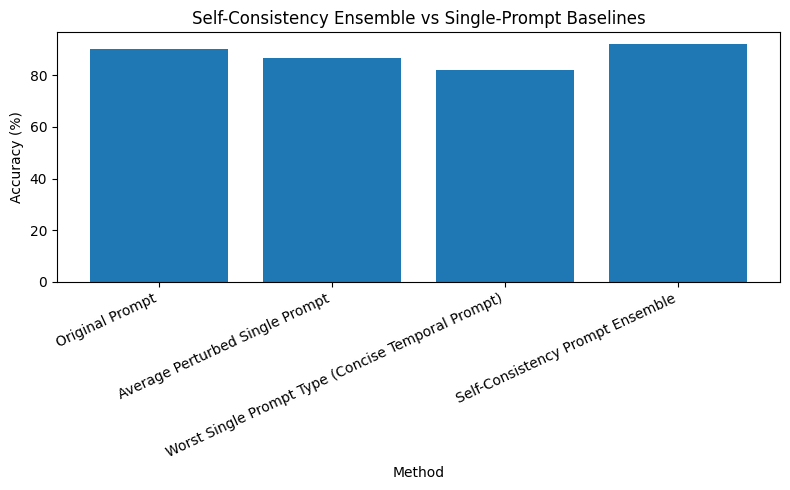

In [15]:
plt.figure(figsize=(8, 5))
plt.bar(hd_comparison["method"], hd_comparison["accuracy_percent"])
plt.ylabel("Accuracy (%)")
plt.xlabel("Method")
plt.title("Self-Consistency Ensemble vs Single-Prompt Baselines")
plt.xticks(rotation=25, ha="right")
plt.tight_layout()
plt.savefig("figure_hd_revised_method_comparison.png", dpi=300)
plt.show()

## Cell 14: Plot Accuracy by Prompt Type

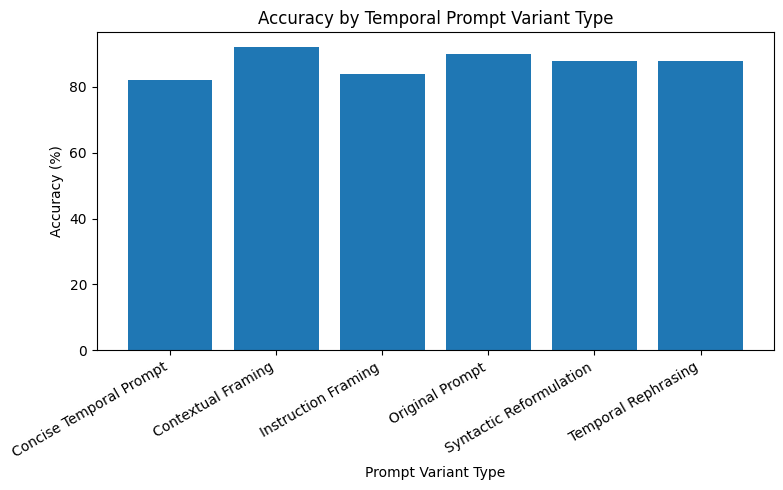

In [16]:
plt.figure(figsize=(8, 5))
plt.bar(accuracy_by_prompt_type["variant_type"], accuracy_by_prompt_type["accuracy_percent"])
plt.ylabel("Accuracy (%)")
plt.xlabel("Prompt Variant Type")
plt.title("Accuracy by Temporal Prompt Variant Type")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.savefig("figure_hd_accuracy_by_prompt_type.png", dpi=300)
plt.show()

## Cell 15: Plot Ensemble Vote Margin Distribution

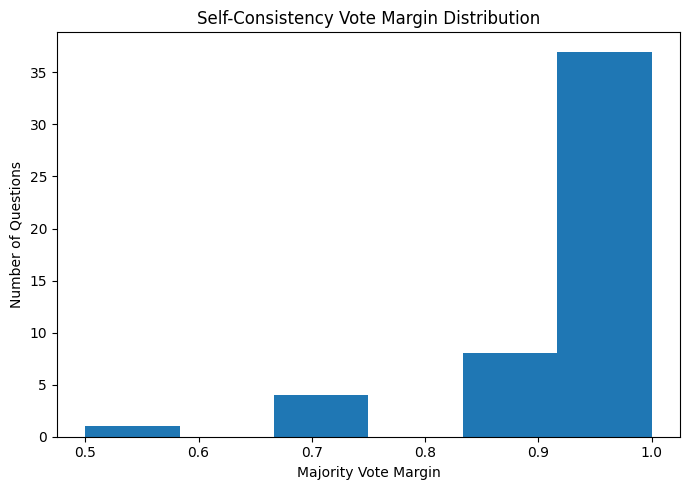

In [17]:
plt.figure(figsize=(7, 5))
plt.hist(df_ensemble["vote_margin"], bins=6)
plt.xlabel("Majority Vote Margin")
plt.ylabel("Number of Questions")
plt.title("Self-Consistency Vote Margin Distribution")
plt.tight_layout()
plt.savefig("figure_hd_vote_margin_distribution.png", dpi=300)
plt.show()

## Cell 16: Save Final HD Summary

In [18]:
hd_summary = {
    "model": MODEL_NAME,
    "num_questions": len(df_base),
    "num_prompt_variants": df_prompts["variant_type"].nunique(),
    "total_model_queries": len(df_prompts),
    "baseline_accuracy": baseline_acc,
    "ensemble_accuracy": ensemble_acc,
    "ensemble_gain": ensemble_gain,
    "baseline_error_rate": baseline_error,
    "ensemble_error_rate": ensemble_error,
    "relative_error_reduction": error_reduction,
    "rescued_by_ensemble": int(len(df_rescued)),
    "broken_by_ensemble": int(len(df_broken)),
    "remaining_ensemble_errors": int(len(df_remaining_errors)),
    "average_vote_margin": df_ensemble["vote_margin"].mean()
}

df_hd_summary = pd.DataFrame([hd_summary])
df_hd_summary.to_csv("hd_final_summary_metrics.csv", index=False)
df_hd_summary

,model,num_questions,num_prompt_variants,total_model_queries,baseline_accuracy,ensemble_accuracy,ensemble_gain,baseline_error_rate,ensemble_error_rate,relative_error_reduction,rescued_by_ensemble,broken_by_ensemble,remaining_ensemble_errors,average_vote_margin
0,Qwen/Qwen2.5-1.5B-Instruct,50,6,300,0.9,0.92,0.02,0.1,0.08,0.2,1,0,4,0.936667
